In [1]:
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [2]:
import boto3
import s3fs

In [3]:
from vqvae_ecg_waveforms_dataset import SEGMENTS

In [4]:
NLEADS = 12
bucket_out = "walkky-ml"
prefix_out = f"aruna-files/vqvae/bert_pretraining/bert_pretrain_results_nleads_{NLEADS}_d384_l8_h12.npz"

s3_client = boto3.client("s3")
s3_fs = s3fs.S3FileSystem()

Text(0, 0.5, 'Accuracy')

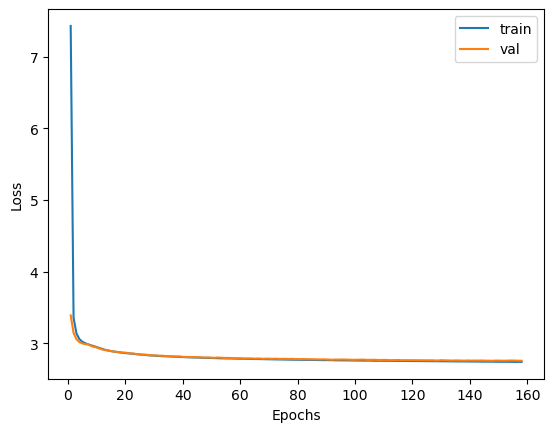

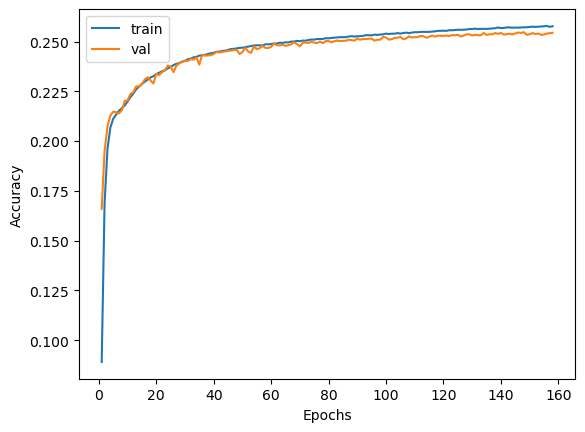

In [5]:
# Training and val results
with s3_fs.open(f"s3://{bucket_out}/{prefix_out}", "rb") as s3_file:
    # Load the compressed data archive
    with np.load(s3_file) as data:
        epochs = data["epoch"]
        train_loss = data["train_loss"]
        train_acc = data["train_accuracy"]
        val_loss = data["val_loss"]
        val_acc = data["val_accuracy"]

# Loss
plt.figure()
plt.plot(epochs, train_loss, label='train')
plt.plot(epochs, val_loss, label='val')
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Loss")

# Accuracy
plt.figure()
plt.plot(epochs, train_acc, label='train')
plt.plot(epochs, val_acc, label='val')
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

In [6]:
train_acc[-10:], val_acc[-10:]

(array([0.257206  , 0.25735541, 0.25748315, 0.25736981, 0.25747807,
        0.25763698, 0.2576887 , 0.25786652, 0.25739472, 0.25770488]),
 array([0.25337166, 0.25366512, 0.25426594, 0.25380024, 0.25400845,
        0.25336934, 0.25353811, 0.25401308, 0.25420911, 0.25443355]))